## 1. Install & Import Libraries

In [1]:
!pip install colorama scikit-learn --quiet

In [2]:
import warnings
warnings.filterwarnings('ignore')

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader, WeightedRandomSampler
# AMP (Automatic Mixed Precision) — speeds up GPU training 2-3x
from torch.cuda.amp import autocast, GradScaler

import torchvision
import torchvision.transforms as transforms
from torchvision.datasets import ImageFolder

from PIL import Image
import colorama
from colorama import Fore, Style

# For extra evaluation metrics
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    f1_score
)

colorama.init()
print(Fore.GREEN + "All libraries imported successfully!" + Style.RESET_ALL)

All libraries imported successfully!


## 2. Dataset Paths

In [3]:
import kagglehub

# Download the dataset from Kaggle
path = kagglehub.dataset_download("vipoooool/new-plant-diseases-dataset")
print("Dataset path:", path)

Root_dir   = path + "/New Plant Diseases Dataset(Augmented)/New Plant Diseases Dataset(Augmented)"
train_dir  = Root_dir + "/train"
valid_dir  = Root_dir + "/valid"
test_dir   = path + "/test"

Diseases_classes = os.listdir(train_dir)
print(f"\nTotal classes found: {len(Diseases_classes)}")

Using Colab cache for faster access to the 'new-plant-diseases-dataset' dataset.
Dataset path: /kaggle/input/new-plant-diseases-dataset

Total classes found: 38


## 3. Data Exploration

Total training images: 70295
Min class size: 1642 | Max class size: 2022


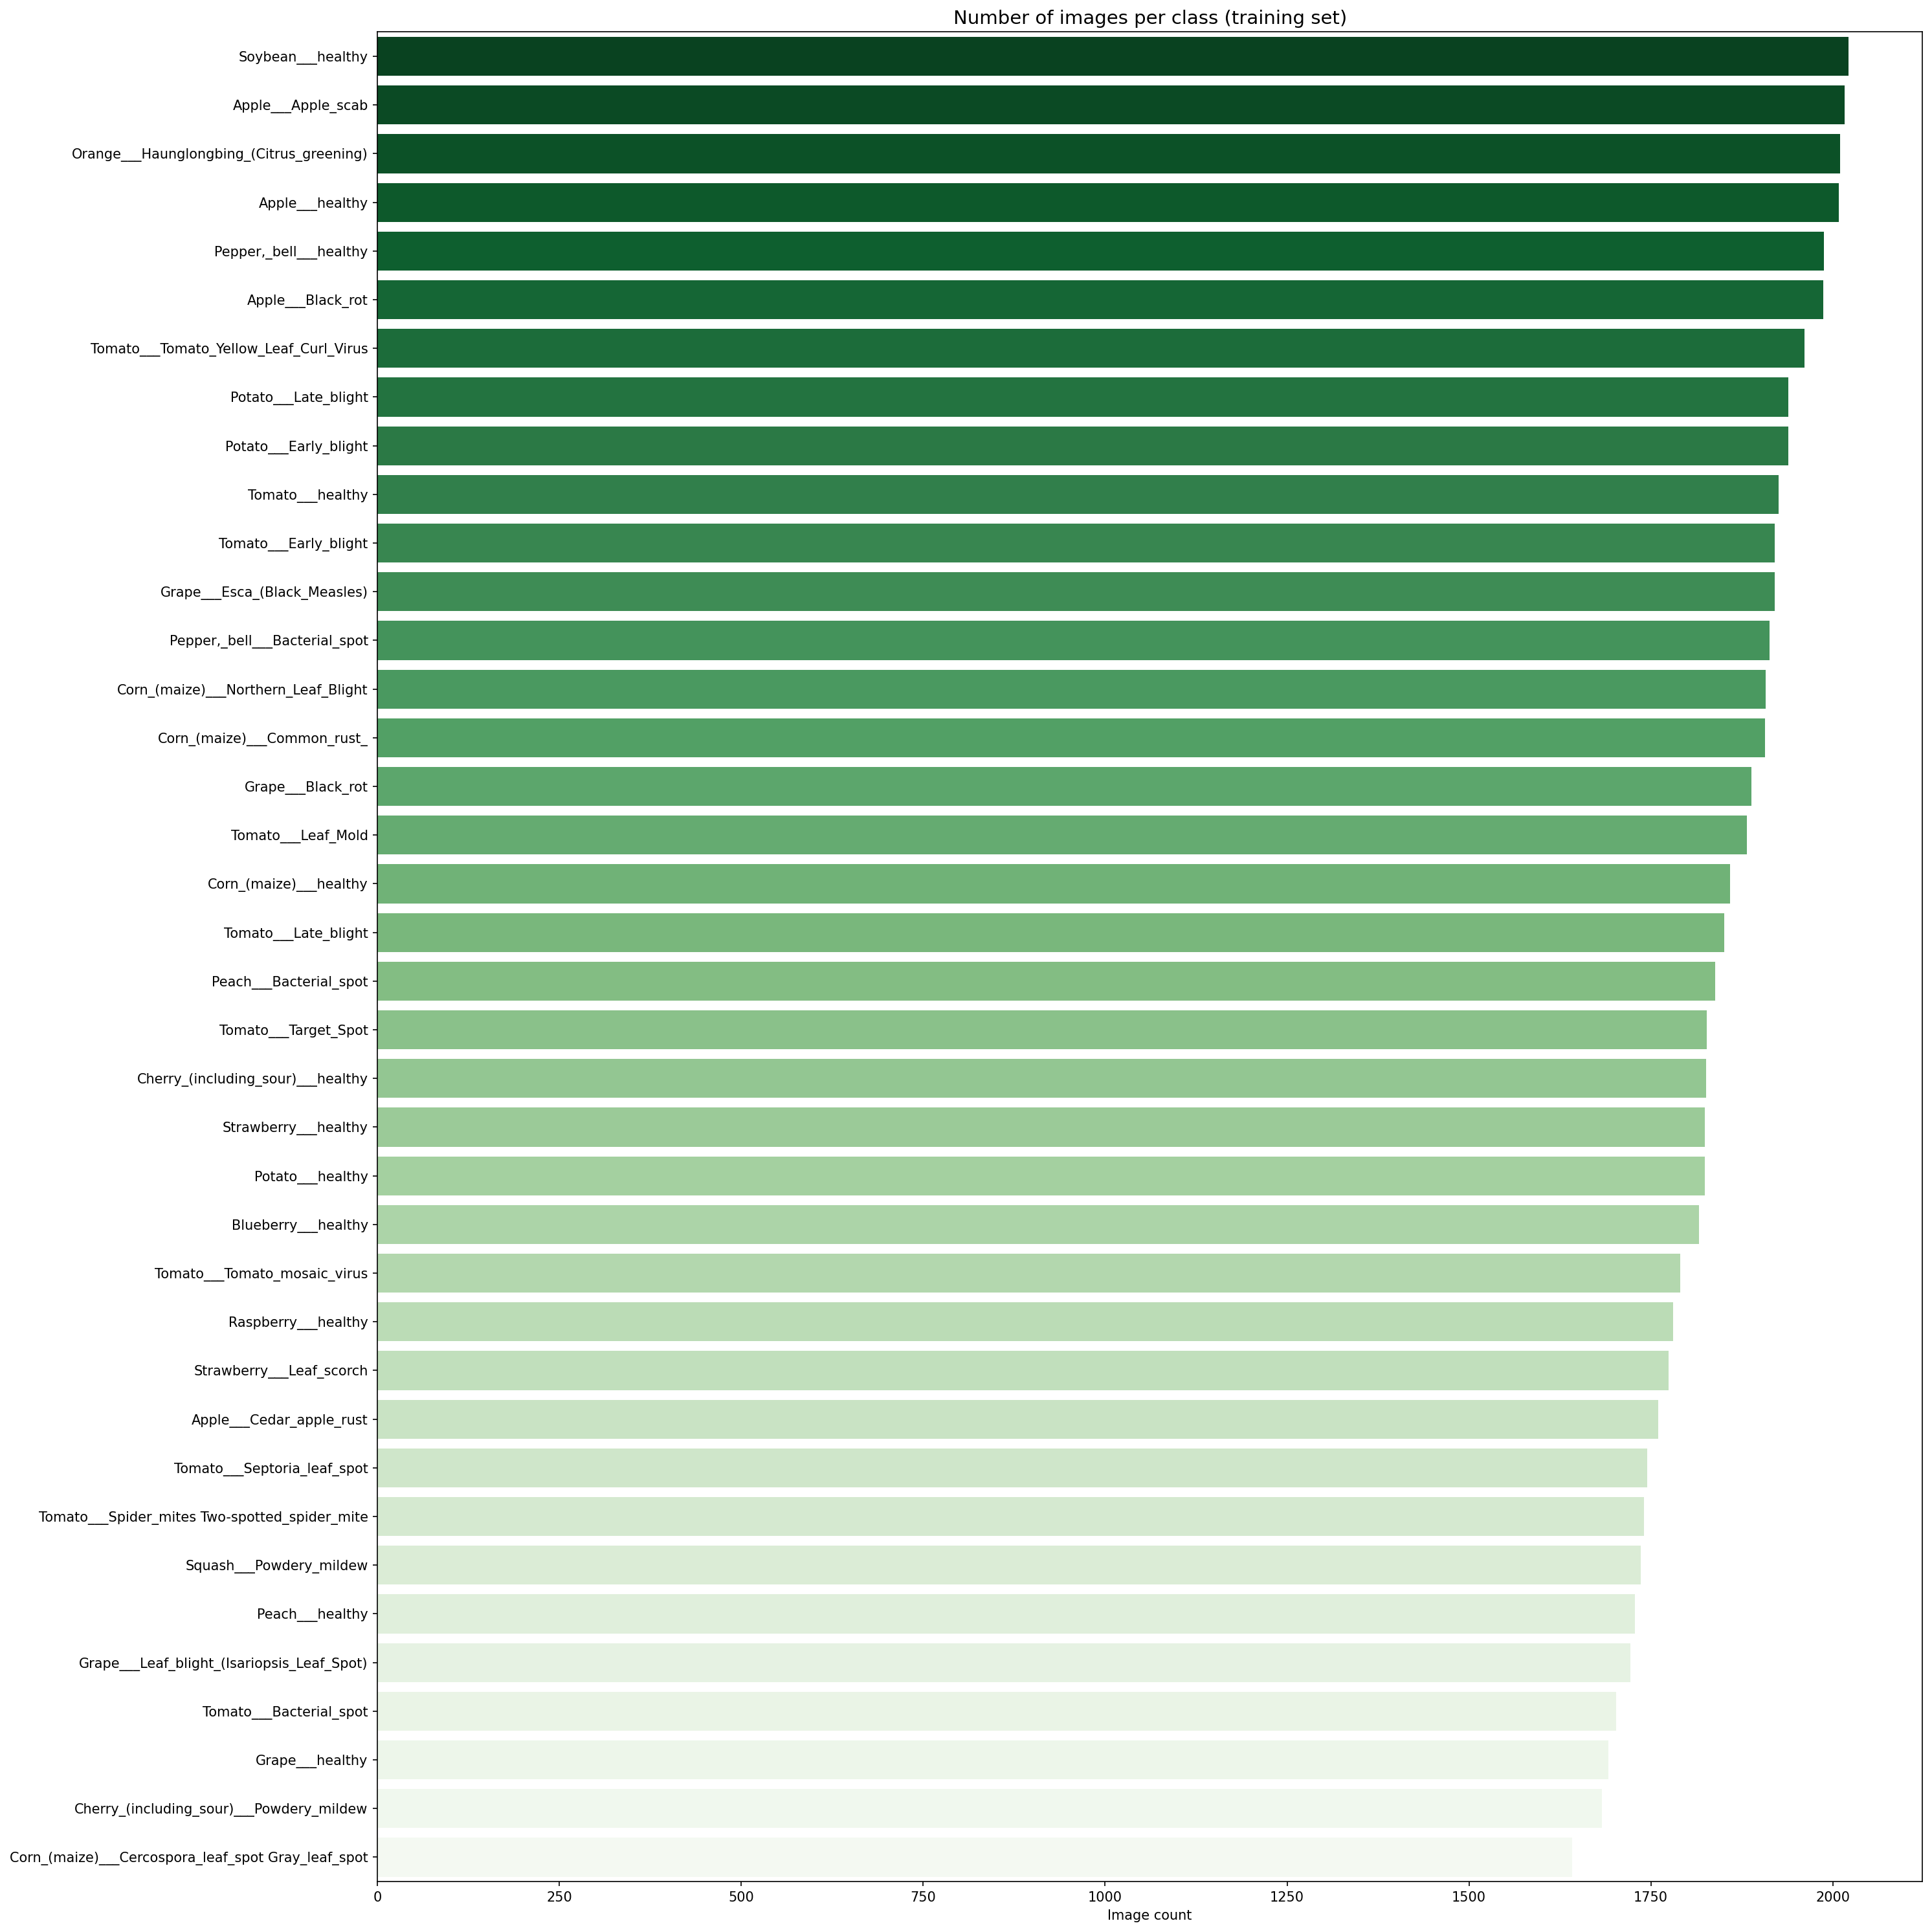

In [4]:
# Count images per class to visualize class distribution
plant_names = []
class_counts = []

for cls in Diseases_classes:
    imgs = os.listdir(os.path.join(train_dir, cls))
    plant_names.append(cls)
    class_counts.append(len(imgs))

total = sum(class_counts)
print(f"Total training images: {total}")
print(f"Min class size: {min(class_counts)} | Max class size: {max(class_counts)}")

# Bar chart of class distribution (important for spotting imbalance)
sorted_pairs = sorted(zip(class_counts, plant_names), reverse=True)
sorted_counts, sorted_names = zip(*sorted_pairs)

plt.figure(figsize=(20, 20), dpi=150)
sns.barplot(x=list(sorted_counts), y=list(sorted_names), palette="Greens_r")
plt.title("Number of images per class (training set)", fontsize=14)
plt.xlabel("Image count")
plt.tight_layout()
plt.show()

## 4. Data Preprocessing & Augmentation

In [5]:
# ImageNet mean and std — standard for models trained on natural images
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

# ----- TRAIN transforms: heavy augmentation to prevent overfitting -----
train_transform = transforms.Compose([
    transforms.RandomHorizontalFlip(p=0.5),         # Randomly mirror left-right
    transforms.RandomVerticalFlip(p=0.3),            # Randomly mirror top-bottom
    transforms.RandomRotation(degrees=30),           # Rotate up to ±30 degrees
    transforms.ColorJitter(
        brightness=0.3,                              # Vary brightness by ±30%
        contrast=0.3,                                # Vary contrast
        saturation=0.3,                              # Vary saturation
        hue=0.1                                      # Slight hue shift
    ),
    transforms.RandomResizedCrop(224, scale=(0.7, 1.0)),  # Random zoom crop to 224x224
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD)
])

# ----- VALID / TEST transforms: no augmentation, only normalize -----
eval_transform = transforms.Compose([
    transforms.Resize(256),                          # Slightly larger than crop size
    transforms.CenterCrop(224),                      # Deterministic center crop
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD)
])

# Load datasets with appropriate transforms
train_dataset = ImageFolder(train_dir, transform=train_transform)
valid_dataset = ImageFolder(valid_dir, transform=eval_transform)
test_dataset  = ImageFolder(test_dir,  transform=eval_transform)

print(f"Train samples : {len(train_dataset)}")
print(f"Valid samples : {len(valid_dataset)}")
print(f"Test  samples : {len(test_dataset)}")
print(f"Classes       : {len(train_dataset.classes)}")

Train samples : 70295
Valid samples : 17572
Test  samples : 33
Classes       : 38


## 5. Class Imbalance — WeightedRandomSampler

Some disease classes have far more images than others.  
Without correction, the model biases toward majority classes.  
`WeightedRandomSampler` gives rarer classes a higher chance of being sampled each batch.

In [6]:
# Count how many samples belong to each class
class_sample_counts = Counter(train_dataset.targets)

# Weight per class = 1 / count  (rarer class → higher weight)
class_weights = {
    cls: 1.0 / count
    for cls, count in class_sample_counts.items()
}

# Assign a weight to every individual sample based on its class
sample_weights = [
    class_weights[label]
    for label in train_dataset.targets
]

# Build the sampler — replacement=True so all classes get equal representation
sampler = WeightedRandomSampler(
    weights=sample_weights,
    num_samples=len(sample_weights),
    replacement=True
)

print(Fore.GREEN + "WeightedRandomSampler ready." + Style.RESET_ALL)
print(f"Min class weight: {min(class_weights.values()):.6f}")
print(f"Max class weight: {max(class_weights.values()):.6f}")

WeightedRandomSampler ready.
Min class weight: 0.000495
Max class weight: 0.000609


## 6. Device Setup

In [7]:
def get_default_device():
    """Return GPU device if available, else CPU."""
    # FIX: added () — without it, the condition was always True
    if torch.cuda.is_available():
        return torch.device("cuda")
    else:
        return torch.device("cpu")


def to_device(data, device):
    """Recursively move tensors or lists/tuples of tensors to a device."""
    if isinstance(data, (list, tuple)):
        return [to_device(x, device) for x in data]
    return data.to(device, non_blocking=True)


class DeviceDataLoader:
    """Wrapper that moves each batch to the target device on iteration."""

    def __init__(self, dataloader, device):
        self.dataloader = dataloader
        self.device = device

    def __iter__(self):
        for batch in self.dataloader:
            yield to_device(batch, self.device)

    def __len__(self):
        return len(self.dataloader)


device = get_default_device()
print(Fore.GREEN + f"Using device: {device}" + Style.RESET_ALL)

Using device: cuda


## 7. DataLoaders


In [8]:
BATCH_SIZE  = 32
NUM_WORKERS = 2

# shuffle=False because sampler already randomizes order
train_loader_raw = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    sampler=sampler,           # WeightedRandomSampler handles shuffling
    num_workers=NUM_WORKERS,
    pin_memory=True
)

valid_loader_raw = DataLoader(
    valid_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=True
)

test_loader_raw = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=True
)

# Wrap loaders to auto-move batches to GPU/CPU
train_dataloader = DeviceDataLoader(train_loader_raw, device)
valid_dataloader = DeviceDataLoader(valid_loader_raw, device)
test_dataloader  = DeviceDataLoader(test_loader_raw,  device)

print(f"Train batches : {len(train_dataloader)}")
print(f"Valid batches : {len(valid_dataloader)}")

Train batches : 2197
Valid batches : 550


## 8. Model Architecture (Custom CNN)

In [9]:
def accuracy(outputs, labels):
    """Compute batch accuracy as a scalar tensor."""
    _, preds = torch.max(outputs, dim=1)
    return torch.tensor(torch.sum(preds == labels).item() / len(preds))


class ImageClassificationBase(nn.Module):
    """Base class providing training/validation step helpers."""

    def training_step(self, batch):
        images, labels = batch
        out = self(images)
        loss = F.cross_entropy(out, labels)
        return loss

    def validation_step(self, batch):
        images, labels = batch
        out  = self(images)
        loss = F.cross_entropy(out, labels)
        acc  = accuracy(out, labels)
        return {'val_loss': loss.detach(), 'val_acc': acc}

    def validation_epoch_end(self, outputs):
        batch_losses = [x['val_loss'] for x in outputs]
        batch_accs   = [x['val_acc']  for x in outputs]
        epoch_loss = torch.stack(batch_losses).mean()
        epoch_acc  = torch.stack(batch_accs).mean()
        return {'val_loss': epoch_loss.item(), 'val_acc': epoch_acc.item()}

    def epoch_end(self, epoch, result):
        print(
            f"Epoch [{epoch:>3}]  "
            f"train_loss: {result['train_loss']:.4f}  "
            f"val_loss: {result['val_loss']:.4f}  "
            f"val_acc: {result['val_acc']:.4f}"
        )

In [10]:
def ConvBlock(in_channels, out_channels, pool=False):
    """
    Conv2d → BatchNorm → ReLU block.
    Optional MaxPool2d(4) when pool=True.
    """
    layers = [
        nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1),
        nn.BatchNorm2d(out_channels),
        nn.ReLU(inplace=True)
    ]
    if pool:
        layers.append(nn.MaxPool2d(4))
    return nn.Sequential(*layers)


class CNN_NeuralNet(ImageClassificationBase):
    """
    Custom CNN with ResNet-style residual skip connections.
    Architecture unchanged from baseline except:
      - Dropout(0.4) added before final Linear layer
    """

    def __init__(self, in_channels, num_diseases):
        super().__init__()

        # --- Encoder blocks ---
        self.conv1 = ConvBlock(in_channels, 64)           # 224 → 224
        self.conv2 = ConvBlock(64, 128, pool=True)        # 224 → 56

        # Residual block 1: output added back to input (skip connection)
        self.res1 = nn.Sequential(
            ConvBlock(128, 128),
            ConvBlock(128, 128)
        )

        self.conv3 = ConvBlock(128, 256, pool=True)       # 56 → 14
        self.conv4 = ConvBlock(256, 512, pool=True)       # 14 → 3

        # Residual block 2
        self.res2 = nn.Sequential(
            ConvBlock(512, 512),
            ConvBlock(512, 512)
        )

        # --- Classifier head ---
        self.classifier = nn.Sequential(
            nn.AdaptiveAvgPool2d((1, 1)),
            nn.Flatten(),
            nn.Dropout(0.4),    # NEW: regularization to prevent overfitting
            nn.Linear(512, num_diseases)
        )

    def forward(self, x):
        out = self.conv1(x)
        out = self.conv2(out)
        out = self.res1(out) + out    # Skip connection
        out = self.conv3(out)
        out = self.conv4(out)
        out = self.res2(out) + out    # Skip connection
        out = self.classifier(out)
        return out


# Instantiate and move model to device
model = to_device(CNN_NeuralNet(3, len(train_dataset.classes)), device)

# Count trainable parameters
total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(Fore.GREEN + f"Model ready. Trainable parameters: {total_params:,}" + Style.RESET_ALL)

Model ready. Trainable parameters: 6,589,734


## 9. Training with Mixed Precision (AMP)

**What AMP does:**  
- Uses `float16` for forward pass (faster, less memory)  
- `GradScaler` prevents gradient underflow during `float16` backprop  
- Falls back to `float32` for numerically sensitive operations  
- Result: ~2-3x speedup on modern GPUs with no accuracy loss

In [11]:
@torch.no_grad()
def evaluate(model, val_loader):
    """Run validation loop and return averaged loss + accuracy."""
    model.eval()
    outputs = [model.validation_step(batch) for batch in val_loader]
    return model.validation_epoch_end(outputs)


def get_lr(optimizer):
    """Read current learning rate from optimizer state."""
    for param_group in optimizer.param_groups:
        return param_group['lr']


def fit_OneCycle(epochs, max_lr, model, train_loader, val_loader,
                 weight_decay=0, grad_clip=None, opt_func=torch.optim.Adam):
    """
    Train the model using:
      - OneCycleLR scheduler (ramps LR up then down for stable convergence)
      - Gradient clipping (prevents exploding gradients)
      - Automatic Mixed Precision / AMP (faster training on GPU)
    Returns a list of per-epoch metric dicts.
    """
    torch.cuda.empty_cache()   # Free any cached GPU memory before starting
    history = []

    optimizer = opt_func(model.parameters(), max_lr, weight_decay=weight_decay)

    # OneCycleLR: linearly increases LR then cosine-anneals back down
    scheduler = torch.optim.lr_scheduler.OneCycleLR(
        optimizer, max_lr,
        epochs=epochs,
        steps_per_epoch=len(train_loader)
    )

    # GradScaler prevents float16 gradient underflow in AMP
    scaler = GradScaler()

    for epoch in range(epochs):
        model.train()
        train_losses = []
        lrs = []

        for batch in train_loader:
            # --- Forward pass in float16 (AMP) ---
            with autocast():
                loss = model.training_step(batch)

            train_losses.append(loss.detach())

            # --- Backward pass with scaled gradients ---
            scaler.scale(loss).backward()

            # Gradient clipping: unscale first, then clip
            if grad_clip:
                scaler.unscale_(optimizer)
                nn.utils.clip_grad_value_(model.parameters(), grad_clip)

            scaler.step(optimizer)     # Update weights
            scaler.update()            # Adjust scaler for next iteration
            optimizer.zero_grad()      # Clear gradients

            lrs.append(get_lr(optimizer))
            scheduler.step()           # Step LR scheduler each batch

        # --- End-of-epoch validation ---
        result = evaluate(model, val_loader)
        result['train_loss'] = torch.stack(train_losses).mean().item()
        result['lrs'] = lrs
        model.epoch_end(epoch + 1, result)
        history.append(result)

    return history

In [12]:
# Hyperparameters
NUM_EPOCHS   = 5
MAX_LR       = 0.01
GRAD_CLIP    = 0.15
WEIGHT_DECAY = 1e-4

# Baseline evaluation before any training
print(Fore.GREEN + "Pre-training validation:" + Style.RESET_ALL)
history = [evaluate(model, valid_dataloader)]
print(history[0])

Pre-training validation:
{'val_loss': 3.6379311084747314, 'val_acc': 0.02596590854227543}


In [13]:
%%time
print(Fore.GREEN + f"Training for {NUM_EPOCHS} epochs..." + Style.RESET_ALL)

history += fit_OneCycle(
    epochs=NUM_EPOCHS,
    max_lr=MAX_LR,
    model=model,
    train_loader=train_dataloader,
    val_loader=valid_dataloader,
    grad_clip=GRAD_CLIP,
    weight_decay=WEIGHT_DECAY,
    opt_func=torch.optim.Adam
)

Training for 5 epochs...
Epoch [  1]  train_loss: 1.3727  val_loss: 0.8399  val_acc: 0.7301
Epoch [  2]  train_loss: 0.7909  val_loss: 0.7826  val_acc: 0.7519
Epoch [  3]  train_loss: 0.5781  val_loss: 0.4341  val_acc: 0.8565
Epoch [  4]  train_loss: 0.3295  val_loss: 0.1693  val_acc: 0.9424
Epoch [  5]  train_loss: 0.1606  val_loss: 0.0776  val_acc: 0.9735
CPU times: user 28min 37s, sys: 1min 23s, total: 30min 1s
Wall time: 1h 8min 37s


## 10. Training Curves

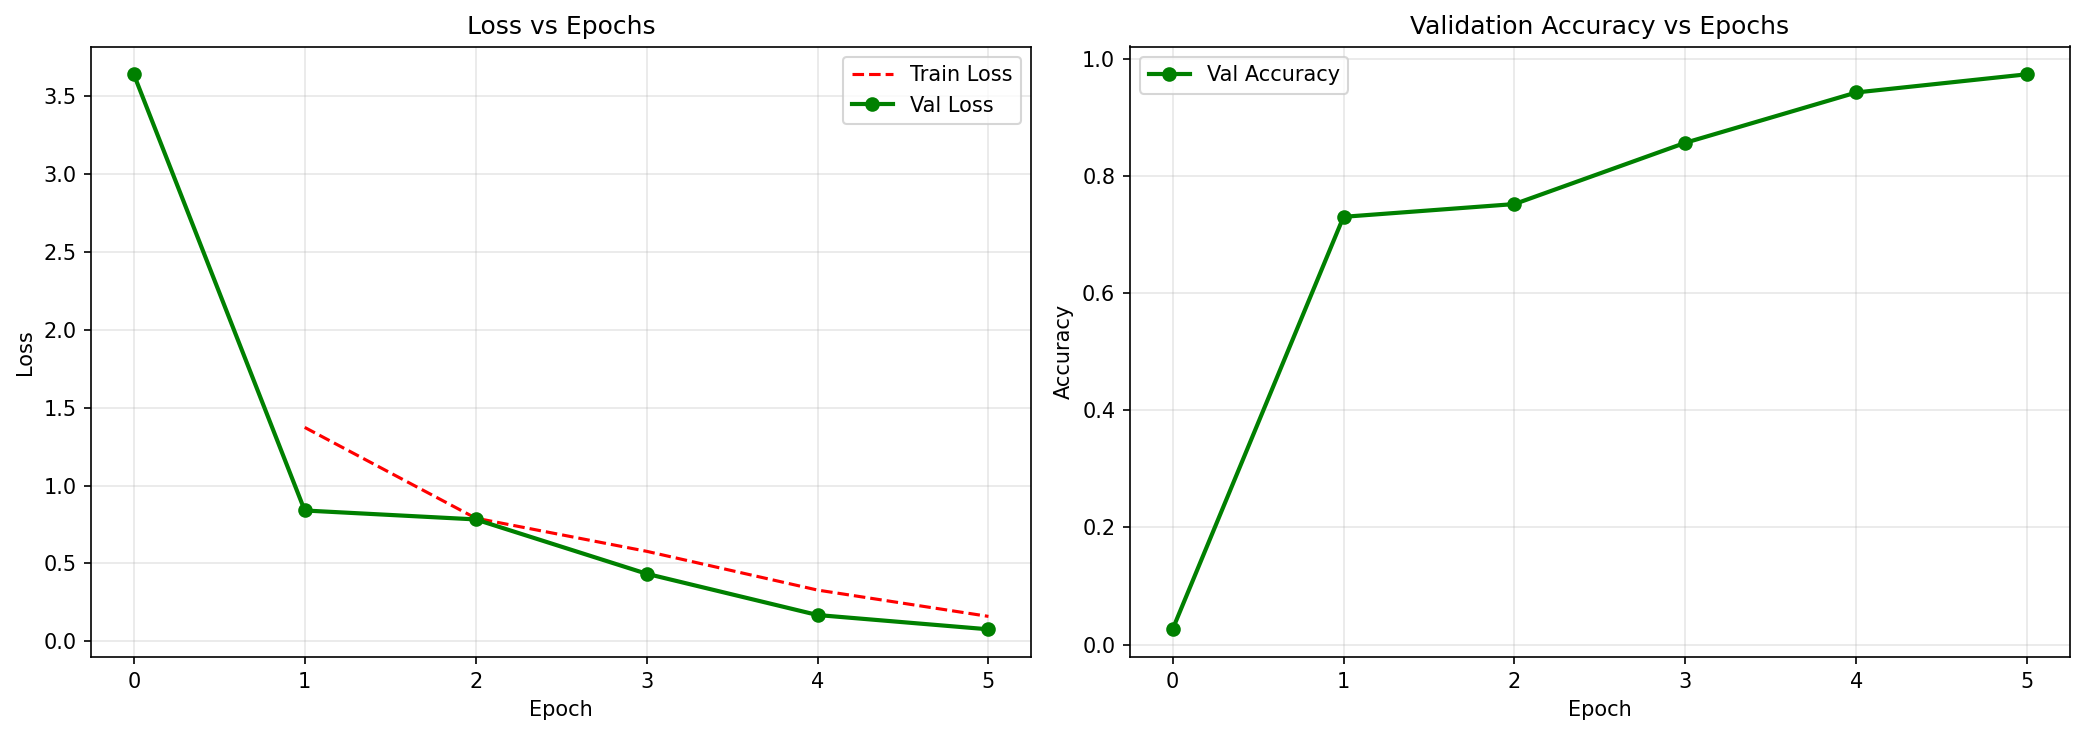

Best validation accuracy: 0.9735 (97.35%)


In [14]:
# Extract metrics from history list
val_acc    = [h['val_acc']   for h in history]
val_loss   = [h['val_loss']  for h in history]
train_loss = [h.get('train_loss') for h in history]

epochs_range = range(len(history))

fig, axes = plt.subplots(1, 2, figsize=(14, 5), dpi=150)

# Loss plot
axes[0].plot(epochs_range, train_loss, 'r--', label='Train Loss')
axes[0].plot(epochs_range, val_loss,   'g-o', label='Val Loss',   linewidth=2)
axes[0].set_title('Loss vs Epochs')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Accuracy plot
axes[1].plot(epochs_range, val_acc, 'g-o', label='Val Accuracy', linewidth=2)
axes[1].set_title('Validation Accuracy vs Epochs')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

best_acc = max(v for v in val_acc if v is not None)
print(Fore.GREEN + f"Best validation accuracy: {best_acc:.4f} ({best_acc*100:.2f}%)" + Style.RESET_ALL)

## 11. Extra Evaluation Metrics — F1 Score & Confusion Matrix


In [15]:
@torch.no_grad()
def get_all_predictions(model, loader):
    """
    Run the model over an entire DataLoader and collect
    true labels and predicted labels as numpy arrays.
    """
    model.eval()
    all_preds  = []
    all_labels = []

    for images, labels in loader:
        outputs = model(images)
        _, preds = torch.max(outputs, dim=1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

    return np.array(all_labels), np.array(all_preds)

In [16]:
print("Running inference on validation set...")
y_true, y_pred = get_all_predictions(model, valid_dataloader)

# --- Overall metrics ---
overall_acc = np.mean(y_true == y_pred)
macro_f1    = f1_score(y_true, y_pred, average='macro')
weighted_f1 = f1_score(y_true, y_pred, average='weighted')

print(Fore.GREEN)
print(f"Overall Accuracy : {overall_acc:.4f} ({overall_acc*100:.2f}%)")
print(f"Macro F1 Score   : {macro_f1:.4f}   (treats all classes equally)")
print(f"Weighted F1 Score: {weighted_f1:.4f}  (weighted by class support)")
print(Style.RESET_ALL)

Running inference on validation set...

Overall Accuracy : 0.9734 (97.34%)
Macro F1 Score   : 0.9732   (treats all classes equally)
Weighted F1 Score: 0.9733  (weighted by class support)



In [17]:
# --- Per-class F1 report ---
class_names = train_dataset.classes
report = classification_report(y_true, y_pred, target_names=class_names, digits=3)
print("Per-class Classification Report:")
print(report)

Per-class Classification Report:
                                                    precision    recall  f1-score   support

                                Apple___Apple_scab      0.998     0.986     0.992       504
                                 Apple___Black_rot      0.984     0.996     0.990       497
                          Apple___Cedar_apple_rust      0.993     0.998     0.995       440
                                   Apple___healthy      0.992     0.980     0.986       502
                               Blueberry___healthy      0.998     0.996     0.997       454
          Cherry_(including_sour)___Powdery_mildew      0.998     0.988     0.993       421
                 Cherry_(including_sour)___healthy      0.964     0.998     0.981       456
Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot      0.965     0.878     0.920       410
                       Corn_(maize)___Common_rust_      0.989     0.987     0.988       477
               Corn_(maize)___Northern_Leaf_Bl

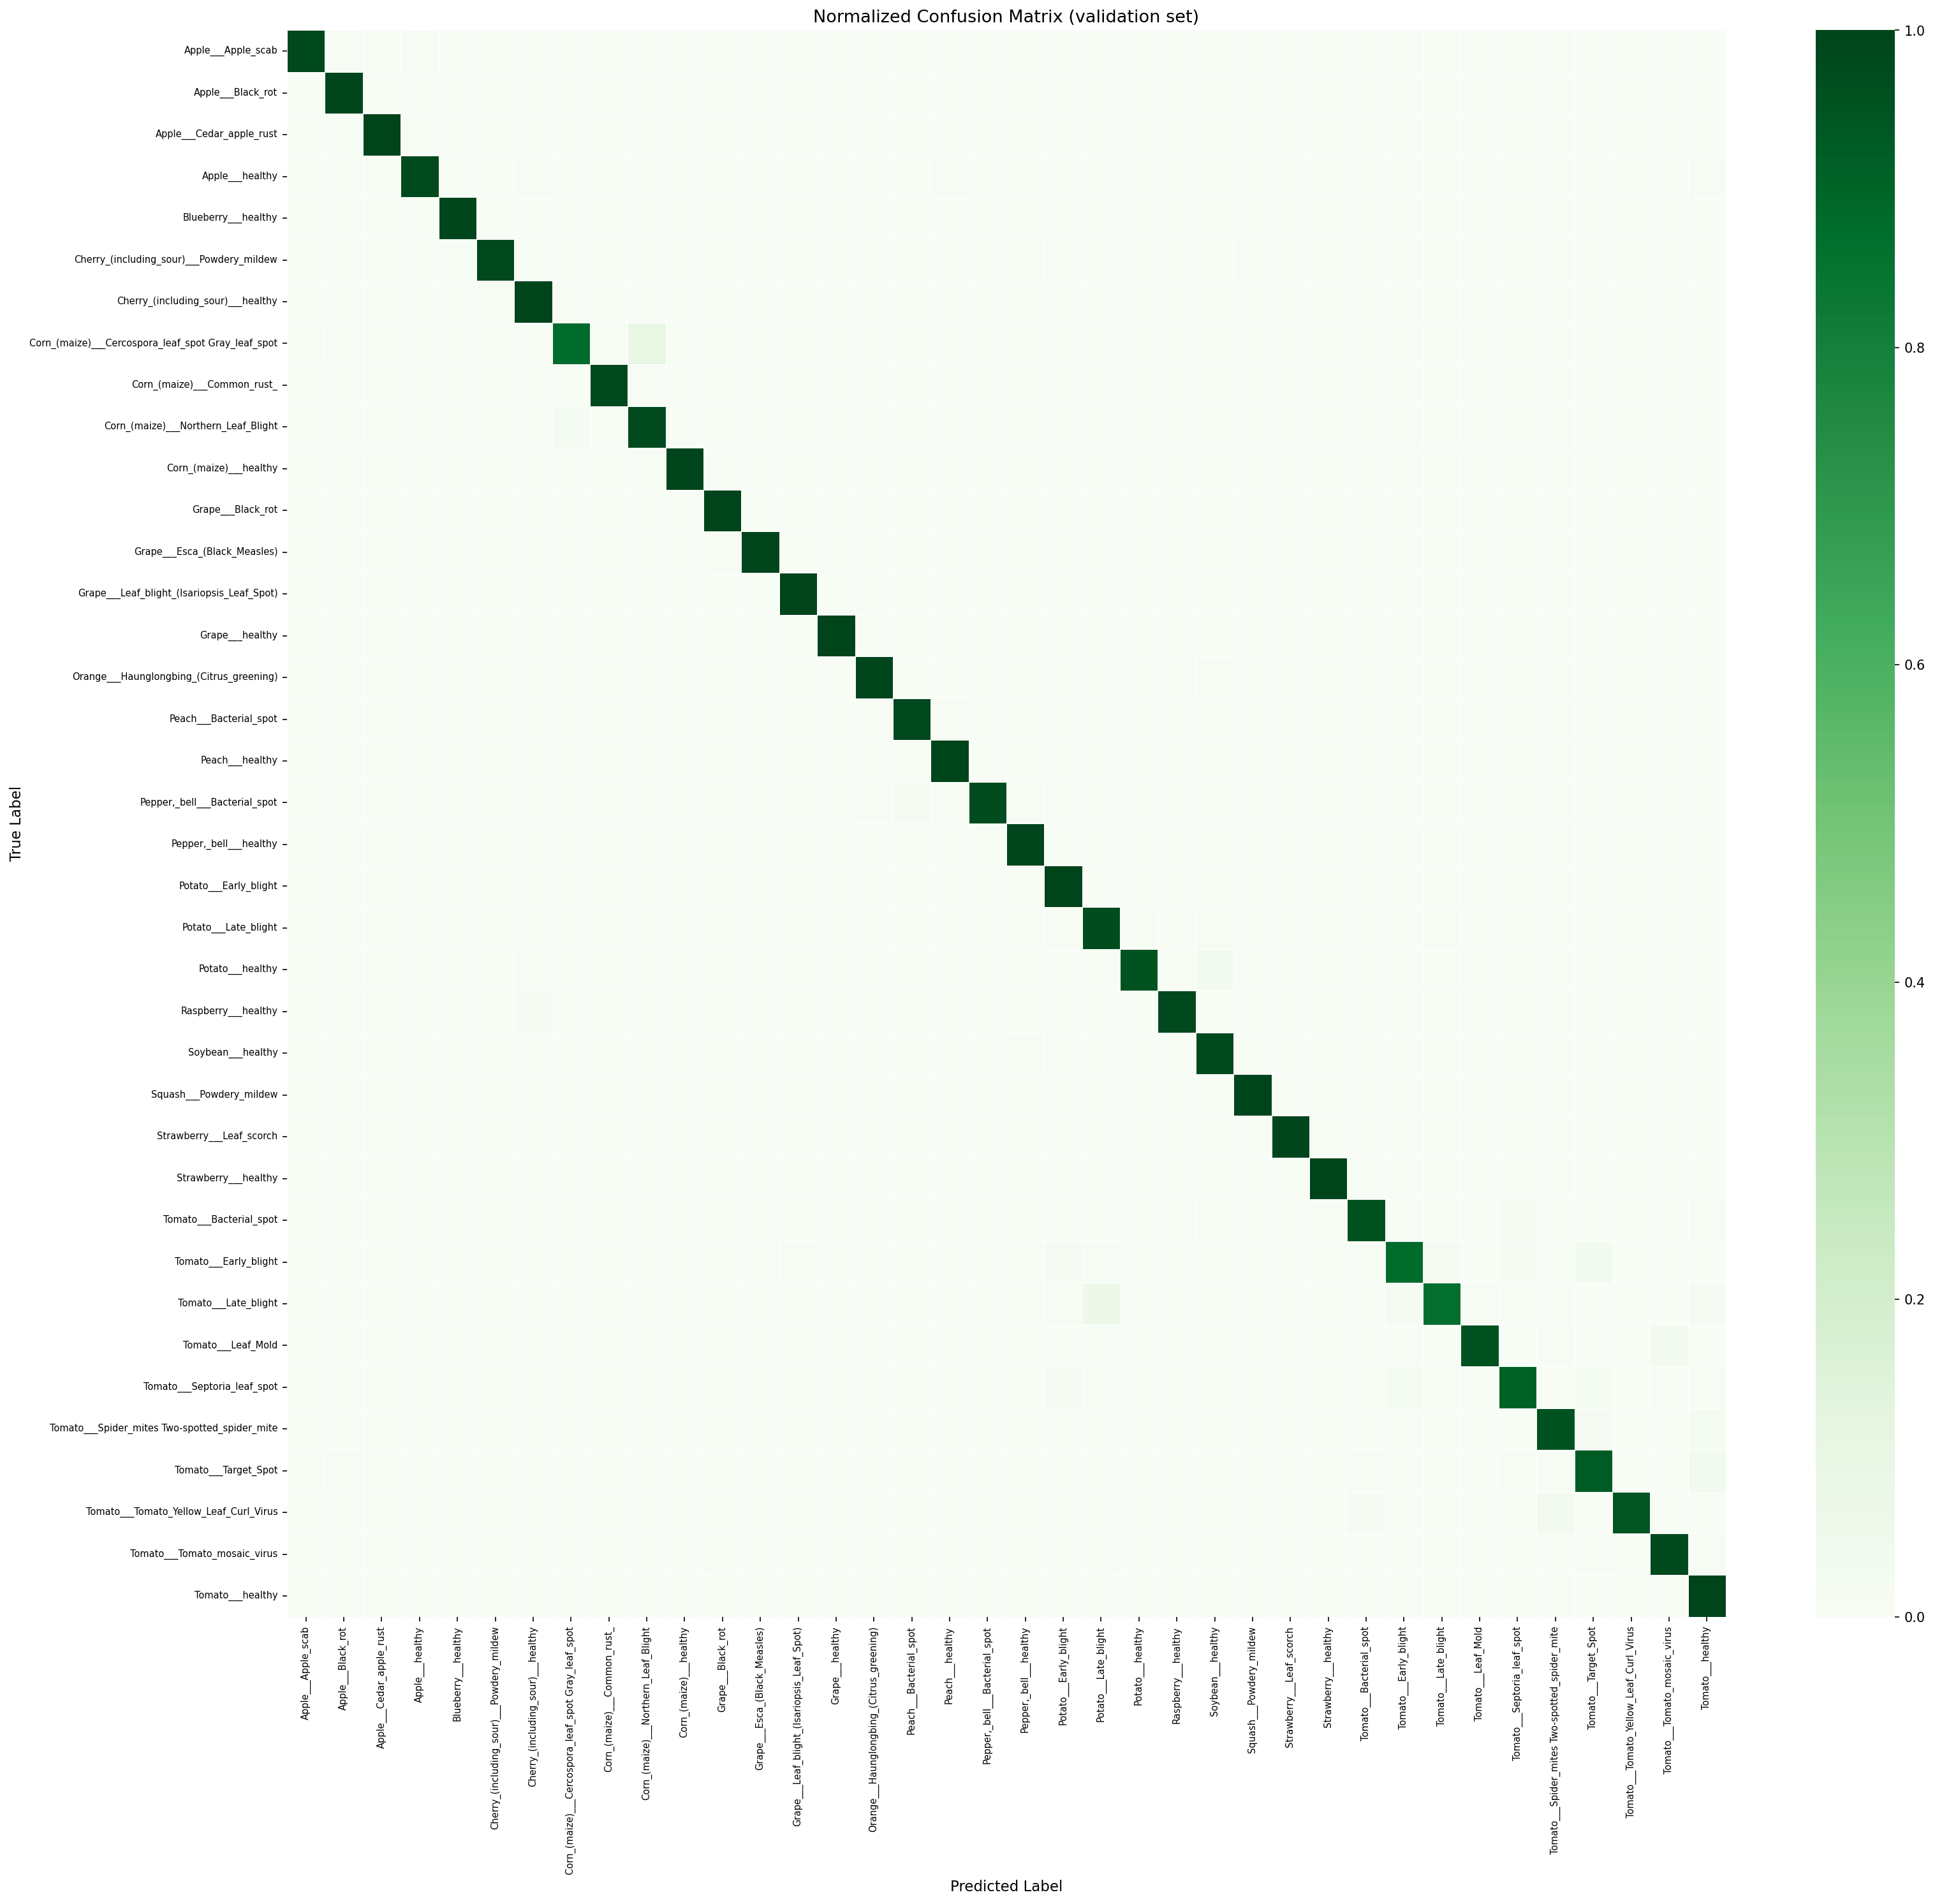


Top 5 most confused class pairs (true → predicted):
  Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot → Corn_(maize)___Northern_Leaf_Blight       (10.49%)
  Tomato___Late_blight                     → Potato___Late_blight                      (7.13%)
  Tomato___Target_Spot                     → Tomato___healthy                          (4.38%)
  Tomato___Early_blight                    → Tomato___Target_Spot                      (3.96%)
  Potato___healthy                         → Soybean___healthy                         (3.73%)


In [18]:
# --- Confusion matrix (normalized) ---
cm = confusion_matrix(y_true, y_pred, normalize='true')  # Row-normalized

plt.figure(figsize=(22, 20), dpi=150)
sns.heatmap(
    cm,
    annot=False,              # Too many classes for per-cell numbers
    fmt='.2f',
    cmap='Greens',
    xticklabels=class_names,
    yticklabels=class_names,
    linewidths=0.3
)
plt.title('Normalized Confusion Matrix (validation set)', fontsize=13)
plt.xlabel('Predicted Label', fontsize=11)
plt.ylabel('True Label',      fontsize=11)
plt.xticks(rotation=90, fontsize=7)
plt.yticks(rotation=0,  fontsize=7)
plt.tight_layout()
plt.show()

# Highlight the top-5 most confused pairs
print("\nTop 5 most confused class pairs (true → predicted):")
cm_no_diag = cm.copy()
np.fill_diagonal(cm_no_diag, 0)   # Ignore correct predictions
for _ in range(5):
    idx = np.unravel_index(cm_no_diag.argmax(), cm_no_diag.shape)
    print(f"  {class_names[idx[0]]:40s} → {class_names[idx[1]]:40s}  ({cm_no_diag[idx]:.2%})")
    cm_no_diag[idx] = 0

## 12. Save Model Checkpoint

In [19]:
checkpoint = {
    'model_state_dict': model.state_dict(),
    'classes': train_dataset.classes,
    'num_classes': len(train_dataset.classes),
    'val_acc': overall_acc,
    'macro_f1': macro_f1,
}

torch.save(checkpoint, 'plant_disease_model.pth')
print(Fore.GREEN + "Model saved to plant_disease_model.pth" + Style.RESET_ALL)

Model saved to plant_disease_model.pth


## 13. Inference on Test Set

In [21]:
print("Test dataset size:", len(test_dataset))

Test dataset size: 33


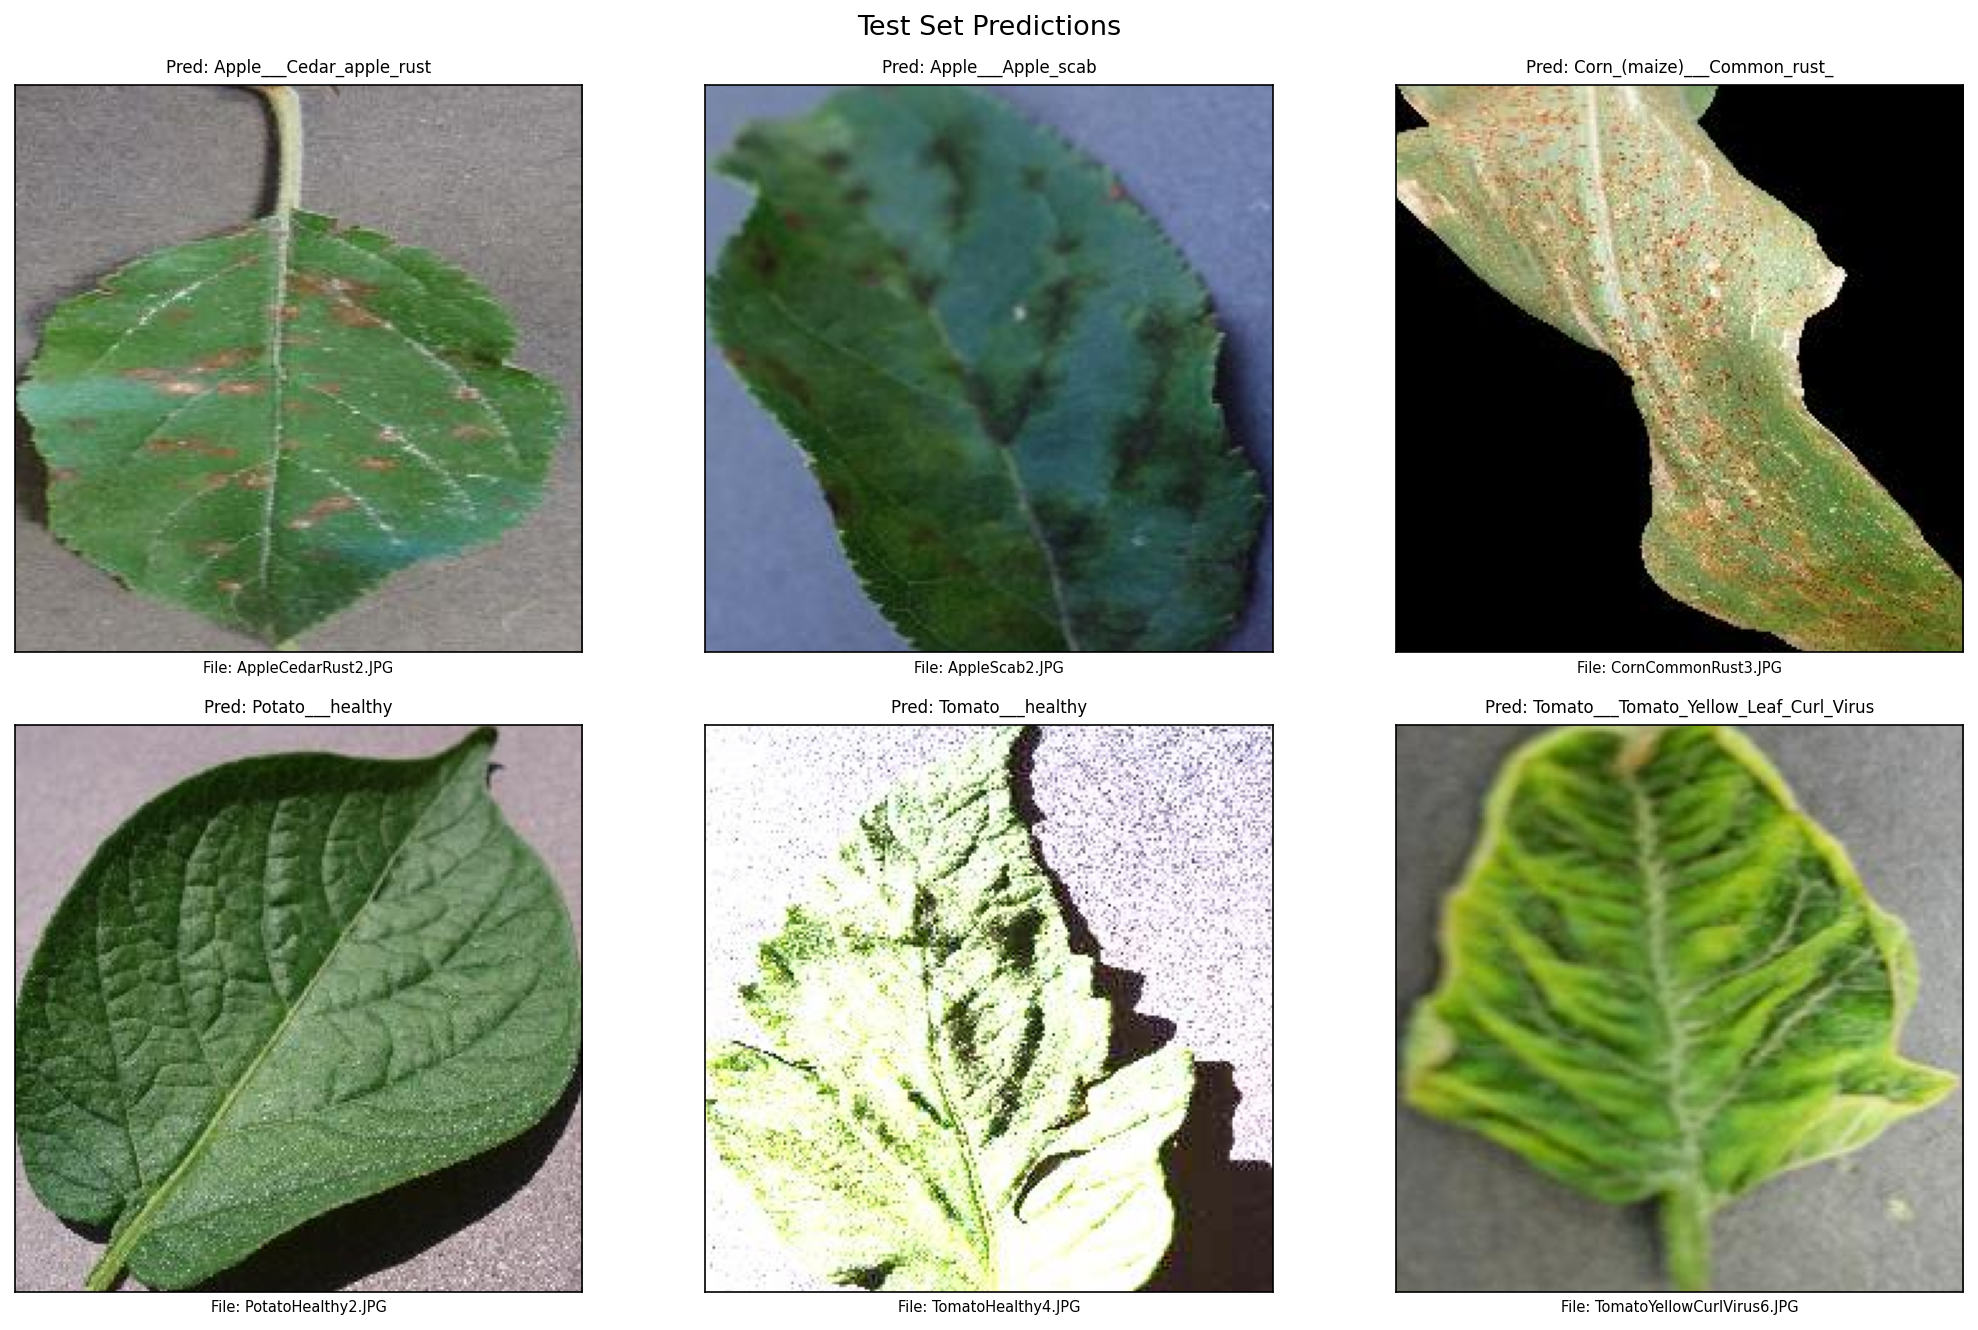

In [22]:
def predict_image(img_tensor, model, class_names):
    """
    Predict the disease class for a single image tensor.
    Returns the class name string.
    """
    model.eval()
    with torch.no_grad():
        xb  = to_device(img_tensor.unsqueeze(0), device)  # Add batch dim
        out = model(xb)
        _, pred = torch.max(out, dim=1)
    return class_names[pred[0].item()]


# Display a grid of test predictions
test_images_list = sorted(os.listdir(os.path.join(test_dir, 'test')))
sample_indices   = [1, 5, 9, 16, 26, 32]

fig, axes = plt.subplots(2, 3, figsize=(14, 9), dpi=150)
axes = axes.flatten()

for ax, idx in zip(axes, sample_indices):
    img_tensor, _ = test_dataset[idx]
    pred_class    = predict_image(img_tensor, model, train_dataset.classes)

    # De-normalize for display (undo ImageNet normalization)
    mean = torch.tensor(IMAGENET_MEAN).view(3, 1, 1)
    std  = torch.tensor(IMAGENET_STD).view(3, 1, 1)
    display_img = (img_tensor * std + mean).clamp(0, 1).permute(1, 2, 0).numpy()

    ax.imshow(display_img)
    ax.set_title(f"Pred: {pred_class}", fontsize=8, wrap=True)
    ax.set_xlabel(f"File: {test_images_list[idx]}", fontsize=7)
    ax.set_xticks([])
    ax.set_yticks([])

plt.suptitle("Test Set Predictions", fontsize=13)
plt.tight_layout()
plt.show()